In [47]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [2]:
ds_new = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_tair.nc")
print(ds_new)

<xarray.Dataset> Size: 791MB
Dimensions:       (time_counter: 2904, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2007-01-03 ... 2007-12-3...
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 791MB ...


In [3]:
print(ds_new.time_counter.values[0])
print(ds_new.time_counter.values[-1])

2007-01-03T00:00:00.000000000
2007-12-31T21:00:00.000000000


In [4]:
def hrdps_pca_num(k):
    print(f"Performing PCA with {k} components...")
    tair = ds_new["tair"]
    X_new = tair.values.reshape(tair.shape[0], -1)
    pca_hrdps = PCA(n_components=k)
    PCs_hrdps = pca_hrdps.fit_transform(X_new)
    print("Variance explained by each PC:")
    print(pca_hrdps.explained_variance_ratio_)
    print("Total variance explained:")
    print(pca_hrdps.explained_variance_ratio_.sum())
    print("-" * 50)

In [5]:
k_values = range(2, 25)
for k in k_values:
    hrdps_pca_num(k)

Performing PCA with 2 components...
Variance explained by each PC:
[0.8855546  0.03881558]
Total variance explained:
0.92437017
--------------------------------------------------
Performing PCA with 3 components...
Variance explained by each PC:
[0.8855546  0.03881565 0.01368488]
Total variance explained:
0.93805516
--------------------------------------------------
Performing PCA with 4 components...
Variance explained by each PC:
[0.8855546  0.03881561 0.01368489 0.01249273]
Total variance explained:
0.9505478
--------------------------------------------------
Performing PCA with 5 components...
Variance explained by each PC:
[0.8855546  0.03881561 0.01368489 0.01249274 0.00585004]
Total variance explained:
0.95639783
--------------------------------------------------
Performing PCA with 6 components...
Variance explained by each PC:
[0.8855546  0.03881563 0.01368489 0.01249273 0.00585004 0.00401502]
Total variance explained:
0.96041286
-----------------------------------------------

22 PCs for HRDPS explain about 98% of the variance.

In [6]:
ds = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_tair_with_latlon.nc")
lat_hr = ds["nav_lat"]
lon_hr = ds["nav_lon"]
corners = { "bottom_left": (float(lat_hr.isel(y=0, x=0)),float(lon_hr.isel(y=0, x=0))),
           "bottom_right": (float(lat_hr.isel(y=0, x=-1)),float(lon_hr.isel(y=0, x=-1))),
           "top_left": (float(lat_hr.isel(y=-1, x=0)),float(lon_hr.isel(y=-1, x=0))),
           "top_right": (float(lat_hr.isel(y=-1, x=-1)),float(lon_hr.isel(y=-1, x=-1)))}

for name, (lat, lon) in corners.items():
    print("name:", name)
    print("lat:", lat)
    print("lon:", lon)

hr_lats = []
hr_lons = []
for coord in corners.values():
    hr_lats.append(coord[0])
    hr_lons.append(coord[1])

lat_min = min(hr_lats)
lat_max = max(hr_lats)
lon_min = min(hr_lons)
lon_max = max(hr_lons)

print(lat_min, lat_max)
print(lon_min, lon_max)

name: bottom_left
lat: 45.61257553100586
lon: 232.6595001220703
name: bottom_right
lat: 46.535892486572266
lon: 240.79672241210938
name: top_left
lat: 51.41788864135742
lon: 230.60208129882812
name: top_right
lat: 52.4603157043457
lon: 239.75860595703125
45.61257553100586 52.4603157043457
230.60208129882812 240.79672241210938


In [7]:
files = sorted(glob.glob('/results/forcing/CanRCM5/*2007*.nc'))
for file in files:
    if "tas" in xr.open_dataset(file).data_vars: #Near-Surface Air Temperature
        ds = xr.open_dataset(file) 
        break

ds_2007 = ds.sel(time=slice("2007-01-03", "2007-12-31")) #Select data from 2007
print(ds_2007)
lat_lr = ds_2007["lat"]
lon_lr = ds_2007["lon"]

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 2904, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB ...
    lat           (rlat, rlon) float64 922kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 1GB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                  

In [8]:
lon_lr = ((lon_lr + 180) % 360) - 180
lon_min = ((lon_min + 180) % 360) - 180
lon_max = ((lon_max + 180) % 360) - 180

mask_lr = (
    (lat_lr >= lat_min) & 
    (lat_lr <= lat_max) &
    (lon_lr >= lon_min) & 
    (lon_lr <= lon_max)
)

i_idx, j_idx = np.where(mask_lr.values) # Finds array indices where mask_lr is True

i_min, i_max = i_idx.min(), i_idx.max()
j_min, j_max = j_idx.min(), j_idx.max()

ds_2007_cut = ds_2007.isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1))
print(ds_2007_cut)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB 232.0 232.3 232.5 ... 239.3 239.6
    lat           (rlat, rlon) float64 12kB 43.66 43.74 43.82 ... 54.29 54.35
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 18MB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realiza

In [9]:
output_file = "/home/dtaneja/analysis-dishika/notebooks/CanRCM5_2007_tas_cut.nc"
ds_2007_cut.to_netcdf(output_file)

In [10]:
ds_cut = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/CanRCM5_2007_tas_cut.nc")
print(ds_cut)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB ...
    lat           (rlat, rlon) float64 12kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 18MB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                          

In [11]:
temp = ds_cut["tas"]
n_time = temp.sizes["time"]
n_rlat = temp.sizes["rlat"]
n_rlon = temp.sizes["rlon"]
X_cut = temp.values.reshape(n_time, n_rlat * n_rlon)

In [12]:
X_cut.shape

(2904, 1521)

In [13]:
pca_canrcm = PCA()
PCs_canrcm_all = pca_canrcm.fit_transform(X_cut)

cumulative_variance = np.cumsum(
    pca_canrcm.explained_variance_ratio_
)

for threshold in [0.90, 0.95, 0.98, 0.99]:
    n_pcs = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold * 100:.0f}% variance explained by {n_pcs} PCs")

90% variance explained by 2 PCs
95% variance explained by 5 PCs
98% variance explained by 18 PCs
99% variance explained by 46 PCs


- Split CanRCM data into training data, validation data and testing data.
- Fit CanRCM PCA using only training data
- Transform only validation and testing data
- Choosing number of CanRCM PCs using validation data: try different number of pcs -> train regression model only using those number of pcs and measure R^2, MSE -> choose the number of PCs based on largest R^3 value


In [14]:
ds_cut

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB ...
    lat           (rlat, rlon) float64 12kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 18MB 286.4 286.3 ... 260.6 260.8
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ...
    product:                        output
    Conventions:                    CF-1.4
    contact:                        cccma_info@ec.gc.ca
    references:                     http://www.cccma.ec.gc.ca/models
    history:                        created: 2024-09-09 21:58:05 by rcm2nc
    data_licence:                   1) GRANT OF LICENCE - The Government of C...

### Chronological split of Temperature data

70% -> training data \
15% -> validation data \
15% -> testing data

In [17]:
ds_cut_sorted = ds_2007_cut.sortby("time")
n_time = ds_cut_sorted.sizes["time"]
train_end = int(0.70 * n_time)
val_end = int(0.85 * n_time)
ds_canrcm_train = ds_cut_sorted.isel(time=slice(0, train_end))
ds_canrcm_val = ds_cut_sorted.isel(time=slice(train_end, val_end))
ds_canrcm_test = ds_cut_sorted.isel(time=slice(val_end, n_time))

In [19]:
print("Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

Training:
2007-01-03 00:00:00 to 2007-09-13 21:00:00
Validation:
2007-09-14 00:00:00 to 2007-11-07 09:00:00
Testing:
2007-11-07 12:00:00 to 2007-12-31 21:00:00


In [22]:
X_canrcm_train = ds_canrcm_train["tas"].values.reshape(ds_canrcm_train.sizes["time"], -1)
X_canrcm_val = ds_canrcm_val["tas"].values.reshape(ds_canrcm_val.sizes["time"], -1)
X_canrcm_test = ds_canrcm_test["tas"].values.reshape(ds_canrcm_test.sizes["time"], -1)
print("Training:", X_canrcm_train.shape)
print("Validation:", X_canrcm_val.shape)
print("Testing:", X_canrcm_test.shape)

Training: (2032, 1521)
Validation: (436, 1521)
Testing: (436, 1521)


In [23]:
pca_canrcm = PCA()
canrcm_train_pcs_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_pcs_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_pcs_all = pca_canrcm.transform(X_canrcm_test)

In [24]:
cumulative_variance_canrcm = np.cumsum(pca_canrcm.explained_variance_ratio_)

for threshold in [0.90, 0.95, 0.98, 0.99]:
    n_pcs = np.searchsorted(cumulative_variance_canrcm, threshold) + 1
    print(f"{threshold * 100:.0f}% variance explained by {n_pcs} CanRCM PCs")

90% variance explained by 2 CanRCM PCs
95% variance explained by 4 CanRCM PCs
98% variance explained by 15 CanRCM PCs
99% variance explained by 40 CanRCM PCs


We will use 15 CanRCM PCs as predictors.

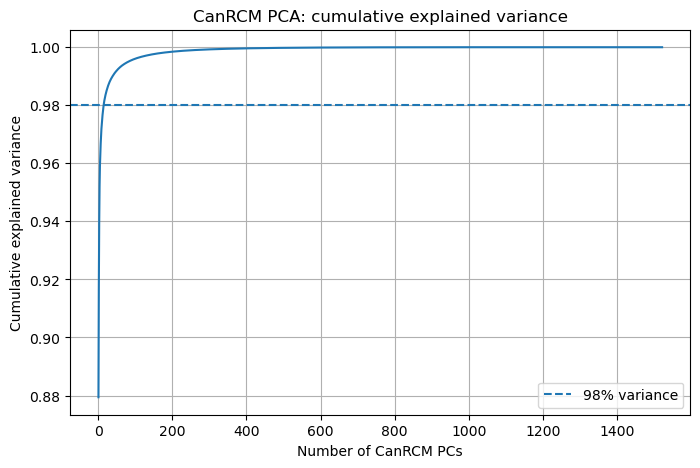

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative_variance_canrcm) + 1),cumulative_variance_canrcm)
plt.axhline(0.98, linestyle="--", label="98% variance")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM PCA: cumulative explained variance")
plt.legend()
plt.grid()
plt.show()

In [28]:
tair_hrdps = ds_new["tair"].sortby("time_counter")
n_hrdps_time = tair_hrdps.sizes["time_counter"]
hrdps_train = tair_hrdps.isel(time_counter=slice(0, train_end))
hrdps_val = tair_hrdps.isel(time_counter=slice(train_end, val_end))
hrdps_test = tair_hrdps.isel(time_counter=slice(val_end, n_hrdps_time))
X_hrdps_train = hrdps_train.values.reshape(hrdps_train.sizes["time_counter"], -1)
X_hrdps_val = hrdps_val.values.reshape(hrdps_val.sizes["time_counter"], -1)
X_hrdps_test = hrdps_test.values.reshape(hrdps_test.sizes["time_counter"], -1)
print("Training:")
print(hrdps_train.time_counter.values[0], "to", hrdps_train.time_counter.values[-1])
print("Validation:")
print(hrdps_val.time_counter.values[0], "to", hrdps_val.time_counter.values[-1])
print("Testing:")
print(hrdps_test.time_counter.values[0], "to", hrdps_test.time_counter.values[-1])

Training:
2007-01-03T00:00:00.000000000 to 2007-09-13T21:00:00.000000000
Validation:
2007-09-14T00:00:00.000000000 to 2007-11-07T09:00:00.000000000
Testing:
2007-11-07T12:00:00.000000000 to 2007-12-31T21:00:00.000000000


In [29]:
pca_hrdps = PCA()
hrdps_train_pcs_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_val_pcs_all = pca_hrdps.transform(X_hrdps_val)
hrdps_test_pcs_all = pca_hrdps.transform(X_hrdps_test)

In [30]:
cumulative_variance_hrdps = np.cumsum(pca_hrdps.explained_variance_ratio_)
for threshold in [0.90, 0.95, 0.98, 0.99]:
    n_pcs = np.searchsorted(cumulative_variance_hrdps, threshold) + 1
    print(f"{threshold * 100:.0f}% variance explained by {n_pcs} HRDPS PCs")

90% variance explained by 2 HRDPS PCs
95% variance explained by 4 HRDPS PCs
98% variance explained by 19 HRDPS PCs
99% variance explained by 69 HRDPS PCs


We will predict 19 HRDPS PCs using 15 CanRCM PCs.

In [31]:
n_canrcm_pcs = 15
n_hrdps_pcs = 19

X_train_reg = canrcm_train_pcs_all[:, :n_canrcm_pcs]
X_val_reg = canrcm_val_pcs_all[:, :n_canrcm_pcs]
X_test_reg = canrcm_test_pcs_all[:, :n_canrcm_pcs]

Y_train_reg = hrdps_train_pcs_all[:, :n_hrdps_pcs]
Y_val_reg = hrdps_val_pcs_all[:, :n_hrdps_pcs]
Y_test_reg = hrdps_test_pcs_all[:, :n_hrdps_pcs]

In [33]:
model = LinearRegression()
model.fit(X_train_reg, Y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
Y_val_pred = model.predict(X_val_reg)

In [ ]:
val_r2 = r2_score(Y_val_reg, Y_val_pred)

print("Validation R²:", val_r2)

Validation R²: 0.14262844622135162


Not good, consider changing the number of CanRCM PCs

In [ ]:
results = []
max_canrcm_pcs = 50

for k in range(1, max_canrcm_pcs + 1):
    X_train_k = canrcm_train_pcs_all[:, :k]
    X_val_k = canrcm_val_pcs_all[:, :k]
    model_k = LinearRegression()
    model_k.fit(X_train_k, Y_train_reg)
    Y_val_pred_k = model_k.predict(X_val_k)

    val_r2 = r2_score(Y_val_reg,Y_val_pred_k,multioutput="variance_weighted")

    results.append({"n_canrcm_pcs": k,"validation_r2": val_r2})

results_df = pd.DataFrame(results)
print(results_df)

    n_canrcm_pcs  validation_r2
0              1       0.449974
1              2       0.582178
2              3       0.587731
3              4       0.606039
4              5       0.614990
5              6       0.620144
6              7       0.626209
7              8       0.629513
8              9       0.632884
9             10       0.624271
10            11       0.633570
11            12       0.650828
12            13       0.659491
13            14       0.664720
14            15       0.664230
15            16       0.660795
16            17       0.666630
17            18       0.667094
18            19       0.665157
19            20       0.667371
20            21       0.667839
21            22       0.692589
22            23       0.693330
23            24       0.696467
24            25       0.684296
25            26       0.693072
26            27       0.692349
27            28       0.689409
28            29       0.695782
29            30       0.698809
30      

In [ ]:
best_row = results_df.loc[results_df["validation_r2"].idxmax()]
best_k = int(best_row["n_canrcm_pcs"])

print("Best number of CanRCM PCs:", best_k)
print("Best validation R²:", best_row["validation_r2"])

Best number of CanRCM PCs: 30
Best validation R²: 0.6988093852996826


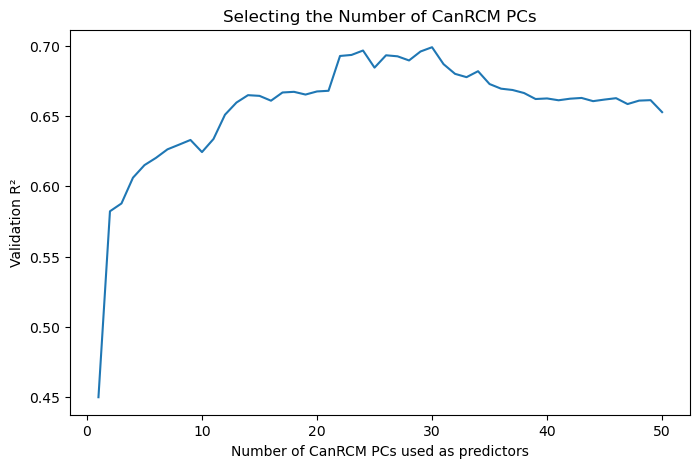

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_r2"])
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation R²")
plt.title("Selecting the Number of CanRCM PCs")
plt.show()

In [43]:
best_k = 30
n_hrdps_pcs = 19
final_model = LinearRegression()
final_model.fit(canrcm_train_pcs_all[:, :best_k],Y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
Y_test_pred = final_model.predict(canrcm_test_pcs_all[:, :best_k])

In [45]:
test_r2 = r2_score(Y_test_reg,Y_test_pred,multioutput="variance_weighted")
print("Test R²:", test_r2)

Test R²: 0.7068015336990356


In [48]:
test_mse = mean_squared_error(Y_test_reg,Y_test_pred)
print("Test MSE:", test_mse)

Test MSE: 15257.5390625


In [49]:
test_r2_each_pc = r2_score(Y_test_reg,Y_test_pred,multioutput="raw_values")
for i, score in enumerate(test_r2_each_pc, start=1):
    print(f"HRDPS PC{i} test R²: {score:.4f}")

HRDPS PC1 test R²: 0.7809
HRDPS PC2 test R²: 0.5991
HRDPS PC3 test R²: 0.4731
HRDPS PC4 test R²: 0.6327
HRDPS PC5 test R²: 0.3874
HRDPS PC6 test R²: -0.3998
HRDPS PC7 test R²: 0.1660
HRDPS PC8 test R²: 0.5361
HRDPS PC9 test R²: -0.0225
HRDPS PC10 test R²: 0.2678
HRDPS PC11 test R²: 0.3080
HRDPS PC12 test R²: 0.1298
HRDPS PC13 test R²: 0.0495
HRDPS PC14 test R²: 0.0374
HRDPS PC15 test R²: -0.1178
HRDPS PC16 test R²: 0.3872
HRDPS PC17 test R²: -0.1140
HRDPS PC18 test R²: 0.0019
HRDPS PC19 test R²: 0.1524


Since this is time series data, chronological splitting is preferred. However, this is temperature data so essentially that means that you are training on a different season and evaluating on a different season which would definitely not give good results. However, trying out random split won't be ideal because there would be data leakage. Nearby observations are not independent because temperature is recorded every three hours. Temperatures only three hours apart are often very similar because they belong to the same weather pattern.

### Random split 

70% train \
15% validation \
15% test

In [50]:
ds_canrcm_random = ds_cut.sortby("time")
tair_hrdps_random = ds_new["tair"].sortby("time_counter")

In [ ]:
X_canrcm_random_all = ds_canrcm_random["tas"].values.reshape(ds_canrcm_random.sizes["time"],-1)
X_hrdps_random_all = tair_hrdps_random.values.reshape(tair_hrdps_random.sizes["time_counter"],-1)

CanRCM shape: (2904, 1521)
HRDPS shape: (2904, 68096)


Still working on trying random split to see results!